# 10 · Diffusion maps

A UMAP is built to show you **groups**. It pulls neighbours together and pushes
everything else apart, so a smooth gradient tends to come out as a chain of islands.

A diffusion map is built for the opposite case. It treats the neighbour graph as a random
walk between cells and asks which directions that walk explores **slowly** — and a slow
direction is exactly what a continuous transition looks like. Where a UMAP gives you
clusters to name, a diffusion map gives you an axis to order cells along.

[Chapter 09](09_paga.ipynb) has already drawn the shape this axis is trying to flatten:
two routes out of the epiblast core, not one. Keep that in mind for section 5, where
the ordering comes out clean and the correlation with real time does not.

| | |
|---|---|
| **1** | Compute it, and read the spectrum |
| **2** | Look at the components |
| **3** | The graph decides what you get |
| **4** | Pseudotime, and the root cell that determines it |
| **5** | Check it before you believe it |
| **6** | Does the axis describe the rest of the plate? |


A more complex explanation of diffusion maps and what is happening behind the functions we use: 

A diffusion map turns the kNN graph (precalculated neighbourhoods) into a Markov transition matrix (the probability of a random walk hopping from one cell to another) and eigendecomposes it, so each diffusion component (DC) is one eigenvector of that matrix.

A cell's value in DCk is its coordinate along that eigenvector: cells with similar values are well connected by short random walks, so DCs often trace continuous trajectories or separate branches.

In [2]:
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import stats

plt.rcParams.update({          # the house style, no package needed
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False,
    "legend.frameon": False, "pdf.fonttype": 42, "ps.fonttype": 42,
})

def panel_grid(n, *, ncols=3, size=(3.6, 3.0)):
    """A figure with `n` axes on a grid, the unused ones removed."""
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, squeeze=False,
                             figsize=(size[0] * ncols, size[1] * nrows))
    flat = axes.ravel()
    for ax in flat[n:]:
        ax.remove()
    return fig, flat[:n]
pd.set_option("display.width", 140)

# The tables live here on Euler. Change this line if your copy is elsewhere.
DATA = Path("/cluster/project/mcsliberali/file_outputs")

cells = sc.read_h5ad(DATA / "mcs2026_controls_downstream.h5ad")
identity = [m for m in cells.uns["panels"]["identity"] if m in set(cells.var_names)]
print(f"{cells.n_obs:,} control cells")
print(f"  graph : {cells.obsp['identity_connectivities'].nnz:,} edges, from chapter 07")
print(f"  states: {list(cells.obs.cell_state.cat.categories)}")

97,177 control cells
  graph : 2,553,740 edges, from chapter 07
  states: ['Epiblast', 'Hypoblast', 'TE-like', 'artefact']


:::{warning}
**Where this chapter writes is the course's folder, not yours.** These chapters were run to
produce the figures you see here, and from chapter 06 onwards they write into
`/cluster/project/mcsliberali/file_outputs`, which you can neither see nor write to.

Load from `data_mcs_2026` once, then save to and read from a folder of your own — see
[Working on Euler](../../setup/working_on_euler.md) for the pattern and the lines to change.
:::

## 1 · Compute it, and read the spectrum

No new distance calculation: a diffusion map is computed **from a neighbour graph you
already have** — in this case the one [chapter 07](07_umap.ipynb) built on the eight identity markers `neighbors_key="identity"`. However, we also calculate the alternative using the 38 markers in `neighbors_key="fullintensity"`.

In [3]:
cells

AnnData object with n_obs × n_vars = 97177 × 38
    obs: 'label', 'well_name', 'ROI', 'is_border_internal', 'is_border_external', 'Organoid_ID', 'timepoint_h', 'condition', 'condition_code', 'well', 'row', 'column', 'is_outlier_condition', 'area', 'eccentricity', 'solidity', 'extent', 'roundness', 'x_in_well', 'y_in_well', 'dapi', 'in_sketch', 'leiden_0.05', 'leiden_0.1', 'leiden_0.3', 'leiden_0.6', 'cluster', 'cell_state', 'fine'
    var: 'family', 'statistic', 'channel', 'round', 'marker', 'species', 'intensity_threshold', 'haralick_threshold', 'failed', 'is_reference', 'is_structural', 'theme', 'column'
    uns: 'X_pca_full', 'X_umap_fullintensity', 'X_umap_identity', 'cell_state_colors', 'condition_colors', 'decode_report', 'draw_graph', 'dropped_wells', 'fine_colors', 'fine_sizes', 'fullintensity', 'identity', 'leiden_0.05', 'leiden_0.1', 'leiden_0.3', 'leiden_0.6', 'leiden_0.6_colors', 'paga', 'panels', 'pca', 'provenance', 'row_colors', 'subset_conditions', 'subset_of', 'subset_

Now that we re-checked the composition of the object we can run the diffmap calculations and look at the eigenvalues for each DC

In [4]:
sc.tl.diffmap(cells, n_comps=15, neighbors_key="identity")
print(f"  X_diffmap: {cells.obsm['X_diffmap'].shape}")

# Move the results of diffmap to a labelled variable - have to do this since there is no key_added argument for this function 
cells.obsm["X_diffmap_identity"] = cells.obsm.pop("X_diffmap")
cells.uns["diffmap_identity_evals"] = cells.uns.pop("diffmap_evals")


evals = pd.Series(cells.uns["diffmap_identity_evals"], index=[f"DC{i}" for i in range(15)])
evals.round(4).head(8)

  X_diffmap: (97177, 15)


DC0    1.0000
DC1    0.9980
DC2    0.9971
DC3    0.9926
DC4    0.9903
DC5    0.9894
DC6    0.9892
DC7    0.9873
dtype: float32

**DC0 is always exactly 1 and always meaningless** — it is the constant vector, the
statement that a random walk left alone forever ends up everywhere. Scanpy keeps it as
column 0 of `X_diffmap`, so every plot below starts at column 1. Forgetting this is the
most common mistake with diffusion maps, and it produces a plot with one axis that is
pure noise.

:::{note}
This DC0 = 1.000 is also what I refer to later as the bug inside scanpy. This causes all diffmap graphs to look flat and without changes in the first dimension.
:::

The eigenvalues (adata.uns['diffmap_evals']) say how slowly each component fades as diffusion proceeds

  DC1 - DC2 gap: 0.0009
  DC2 - DC3 gap: 0.0045


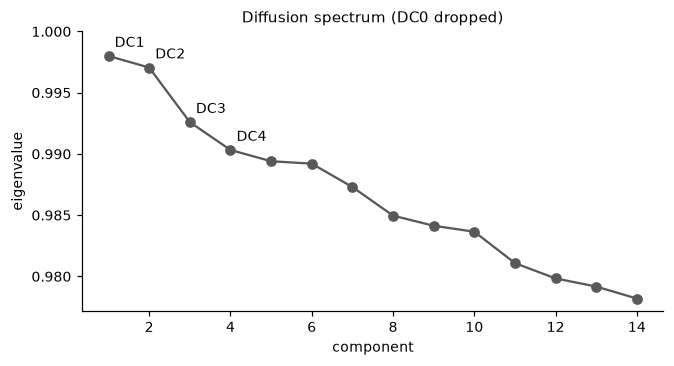

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(range(1, 15), evals.values[1:], marker="o", color="0.35")
ax.set(xlabel="component", ylabel="eigenvalue", title="Diffusion spectrum (DC0 dropped)")
ax.set_ylim(top=1.0)
for i in range(1, 5):
    ax.annotate(f"DC{i}", (i, evals.values[i]), textcoords="offset points",
                xytext=(4, 6), fontsize=9)
fig.tight_layout()

print(f"  DC1 - DC2 gap: {evals.iloc[1] - evals.iloc[2]:.4f}")
print(f"  DC2 - DC3 gap: {evals.iloc[2] - evals.iloc[3]:.4f}")

:::{important}
**The eigenvalues decrease smoothly, and that tells us something.**

A diffusion map imagines a walker hopping from cell to cell, preferring to step to cells
with similar expression profiles. Each diffusion component (DC) describes one pattern in
where this walker tends to wander, and its eigenvalue says how long that pattern survives
as the walk goes on. Values close to 1 mean large-scale structure that dominates the data;
lower values mean finer, more local detail.

If the data contained a few clearly separate groups, the walker would tend to stay trapped
inside each one, rarely crossing to another. That would show up as a few eigenvalues very
close to 1, followed by a sharp drop to the rest. This drop is called an eigengap.

Here there is no such gap. The eigenvalues start at about 0.99 and shrink by only
thousandths from one component to the next, so no small set of components stands out.
This suggests the cells form one continuous landscape with gradual transitions, rather
than a few distinct branches. It also means the eigenvalues alone cannot tell us how many
DCs are worth keeping, so that choice has to come from looking at the components
themselves.
:::

The two cases side by side, on data simple enough to see them:

```{image} ../../images/diffmap_eigengap.png
:alt: Left, three separate clusters: a walker started in one fills that cluster and never escapes, and the spectrum shows three eigenvalues at 1 then a sharp drop, the eigengap. Right, one continuous manifold: the walker keeps drifting along it and the eigenvalues decline slowly and evenly, with no gap.
:width: 100%
```

**Left** is what separate groups look like: the walker starts at the star and fills its own
group, but never crosses to another, so three eigenvalues sit at 1 and then the spectrum
falls off a cliff. **Right** is a continuum: nothing stops the walker drifting along it, so
no small set of components dominates and the eigenvalues slide down evenly.

Our spectrum above is the right-hand case.

## 2 · Look at the components

To do this, we actually cannot simply take the `sc.pl.diffmap` function, because it has the bug we previously described in which we actually plot DC0 vs DC1, instead of DC1 vs DC2, you can see how such a graph would look here: https://scanpy.readthedocs.io/en/stable/api/generated/scanpy.pl.diffmap.html

Instead we will use a custom variation by giving the data to `sc.pl.embedding`. Described below.

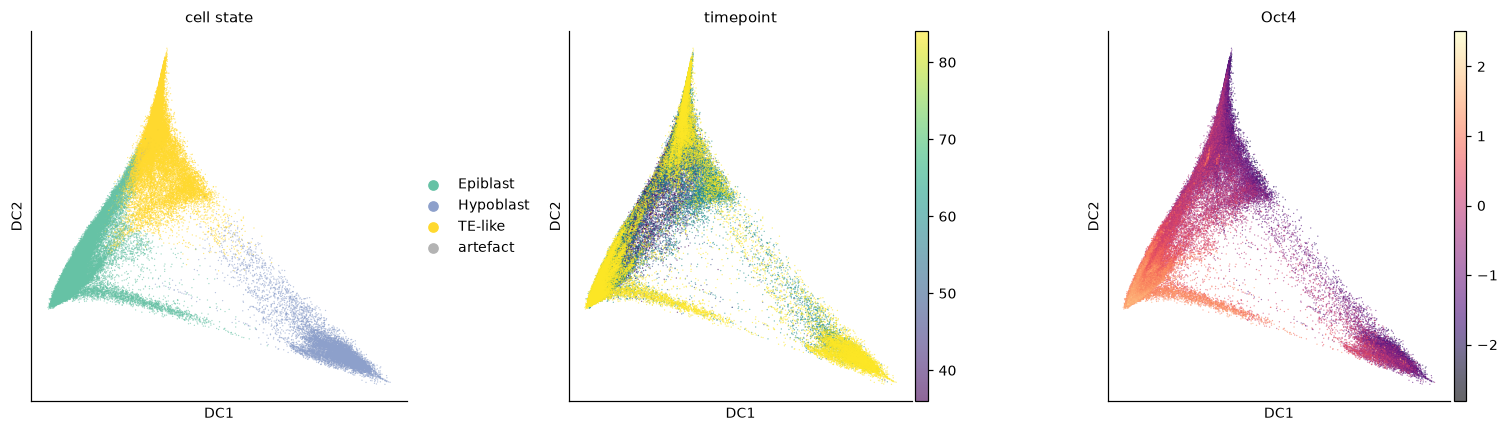

In [6]:
# Drop the steady-state column so the new basis starts at DC1
cells.obsm["X_dc"] = cells.obsm["X_diffmap_identity"][:, 1:]
cells.obs["timepoint_num"] = cells.obs["timepoint_h"].astype(int)  # numeric -> colorbar

fig, axes = panel_grid(3, ncols=3, size=(4.6, 4.0))

# Here we define what we wanna plot -> (##variable##, ##graph title##, ##colors to be used##)
panels = [
    ("cell_state",    "cell state", dict(palette="Set2")),
    ("timepoint_num", "timepoint",  dict(cmap="viridis")),
    ("Oct4",          "Oct4",       dict(cmap="magma", use_raw=False)),
]
for ax, (key, title, kw) in zip(axes, panels):
    sc.pl.embedding(cells, basis="dc", color=key, title=title,
                    size=3, alpha=0.6, ax=ax, show=False, **kw)
    ax.set(xlabel="DC1", ylabel="DC2")
fig.tight_layout()

In [7]:
dc = cells.obsm["X_diffmap_identity"]
oct4 = np.asarray(cells[:, "Oct4"].X).ravel()
pd.DataFrame({
    "Spearman vs DC1": {
        "Oct4":      stats.spearmanr(dc[:, 1], oct4).statistic,
        "GATA4":     stats.spearmanr(dc[:, 1], np.asarray(cells[:, "GATA4"].X).ravel()).statistic,
        "PC1":       stats.spearmanr(dc[:, 1], cells.obsm["X_pca"][:, 0]).statistic,
        "DAPI":      stats.spearmanr(dc[:, 1], cells.obs.dapi).statistic,
        "timepoint": stats.spearmanr(dc[:, 1], cells.obs.timepoint_h.astype(int)).statistic,
    }
}).round(3)

,Spearman vs DC1
Oct4,-0.852
GATA4,0.285
PC1,-0.662
DAPI,-0.517
timepoint,-0.030


We cannot actually check loadings for DCs since, we just have an eigenvalue for every cell. Instead we can use correlations to show correlations between DCs and markers or metadata in our data. Here we show some correlations between DC1 and Spearman, you can see Oct 4 is highly correlated with DC1. Indicating changes in differentiation along DC1, as OCT4 is a marker of stem cells/pluripotency.

:::{note}
**Read the magnitude; the sign is irrelevant** An eigenvector multiplied by −1 is the
same eigenvector, so which end of DC1 comes out positive depends on the numerical
solver, not on the data — and it can flip between runs on the same input. The same is
true of PCA loadings.
:::

## 3 · Running diffusion maps on the 38 markers

Build the graph
[chapter 07](07_umap.ipynb) decided against — the PCA of all 38 markers — run exactly the
same call on it, and see what changes.

In [8]:
sc.tl.diffmap(cells, n_comps=10, neighbors_key="fullintensity")

# Same as before - save this new diffmap calculation in a new layer with trackable name
cells.obsm["X_diffmap_fullintensity"] = cells.obsm.pop("X_diffmap")
cells.uns["diffmap_fullintensity_evals"] = cells.uns.pop("diffmap_evals")

alt_dc = cells.obsm["X_diffmap_fullintensity"]

comparison = pd.DataFrame({
    "identity graph (8 markers)": {
        "Oct4": stats.spearmanr(dc[:, 1], np.asarray(cells[:, "Oct4"].X).ravel()).statistic,
        "PC1 — overall brightness": stats.spearmanr(dc[:, 1], cells.obsm["X_pca"][:, 0]).statistic,
    },
    "PCA graph (all 38 markers)": {
        "Oct4": stats.spearmanr(alt_dc[:, 1], np.asarray(cells[:, "Oct4"].X).ravel()).statistic,
        "PC1 — overall brightness": stats.spearmanr(alt_dc[:, 1], cells.obsm["X_pca"][:, 0]).statistic,
    },
}).round(3)
comparison.index.name = "|Spearman| of DC1 vs"
comparison.abs()

,identity graph (8 markers),PCA graph (all 38 markers)
|Spearman| of DC1 vs,,
Oct4,0.852,0.770
PC1 — overall brightness,0.662,0.935


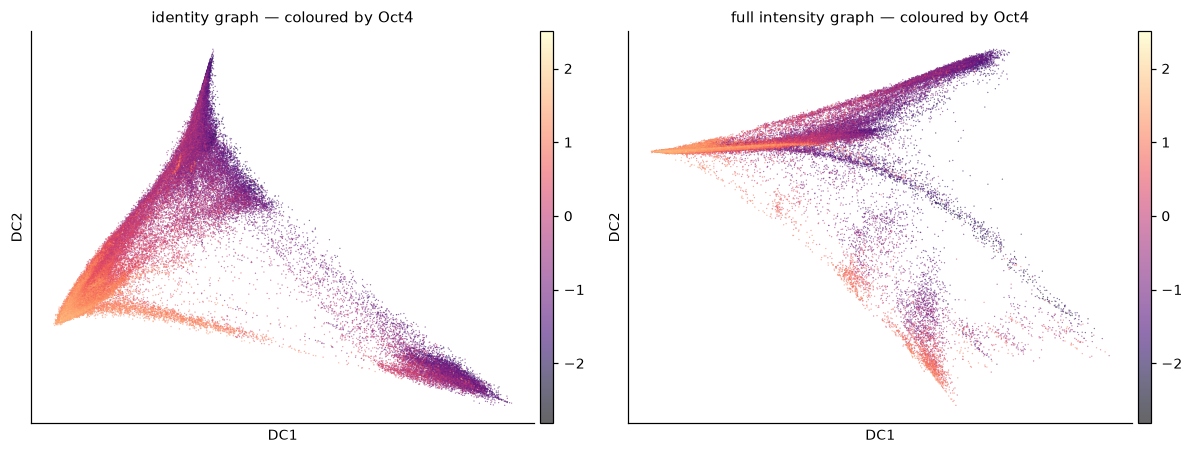

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (basis, label) in zip(axes, [("diffmap_identity", "identity graph"),
                                     ("X_diffmap_fullintensity", "full intensity graph")]):
    sc.pl.embedding(cells, basis=basis, dimensions=(1, 2), color="Oct4",
                    use_raw=False, cmap="magma", size=3, alpha=0.6,
                    title=f"{label} — coloured by Oct4", ax=ax, show=False)
    ax.set(xlabel="DC1", ylabel="DC2")
fig.tight_layout()

:::{warning}
**Same algorithm, same cells, different meaning.** On the identity graph DC1 is a
pluripotency axis. On the 38-marker graph it is largely
[PC1](06_pca.ipynb) — how brightly the cell stained. Chapter 07 rejected that graph on a
batch-effect argument; here is the same choice arriving from the other direction.

This is why we also remove most markers, from the data and build on those we use to determine cell states. Then we use the others as projections to the data, to understand other effects
:::

## 4 · Pseudotime

Diffusion pseudotime turns the axis into a number per cell: the diffusion distance from a
**root cell** you choose. Everything about the result follows from that choice, so make
it deliberately and write it down.

The defensible root here is a cell as close to the starting state as the data allows:
**epiblast, at the earliest timepoint, with the most Oct4**.

Every one of those three conditions comes from knowing what was put in the wells. None
comes from the diffusion map — picking "the cell at the end of DC1" would be circular,
and, since the sign of DC1 is arbitrary, would silently choose the opposite end on a
rerun.

In [10]:
candidates = np.where((cells.obs.cell_state.astype(str) == "Epiblast")
                      & (cells.obs.timepoint_h.astype(int) == 36))[0]
root = int(candidates[np.argmax(oct4[candidates])])
cells.uns["iroot"] = root

print(f"  {len(candidates)} candidate cells (epiblast, 36 h)")
print(f"  root: cell {root}, well {cells.obs.well.iloc[root]}, "
      f"Oct4 {oct4[root]:+.2f} SDs (max of the candidates)")


  7688 candidate cells (epiblast, 36 h)
  root: cell 63750, well M04, Oct4 +1.42 SDs (max of the candidates)


It is worth looking at where that cell actually sits. The pool it was chosen
from is every epiblast cell at 36 hours; the star is the one with the most Oct4.
If the star does not sit at the edge of the epiblast region, the ordering below
will start from the middle of the data and run outwards in both directions.

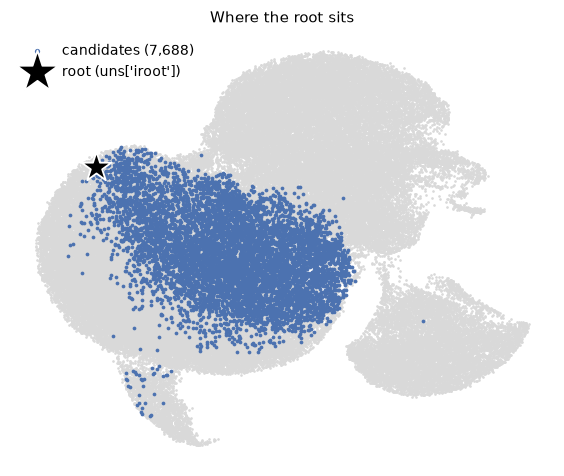

In [11]:
umap = cells.obsm["X_umap"]

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.scatter(umap[:, 0], umap[:, 1], s=3, c="0.85", linewidth=0)
ax.scatter(umap[candidates, 0], umap[candidates, 1], s=6, c="#4C72B0",
           linewidth=0, label=f"candidates ({len(candidates):,})")
ax.scatter(*umap[root], marker="*", s=420, c="black", edgecolor="white",
           linewidth=1.2, zorder=5, label="root (uns['iroot'])")
ax.set(xticks=[], yticks=[], title="Where the root sits")
ax.legend(loc="best", markerscale=1.4)
for side in ("top", "right", "bottom", "left"):
    ax.spines[side].set_visible(False)
fig.tight_layout()

In [12]:
sc.tl.dpt(cells, neighbors_key="identity")
pseudotime = cells.obs.dpt_pseudotime.values
print(f"  pseudotime: {np.isfinite(pseudotime).sum():,} of {len(pseudotime):,} cells finite, "
      f"range {pseudotime.min():.2f} to {pseudotime.max():.2f}")

  pseudotime: 97,177 of 97,177 cells finite, range 0.00 to 1.00


### Pseudotime on the PAGA-initialised UMAP

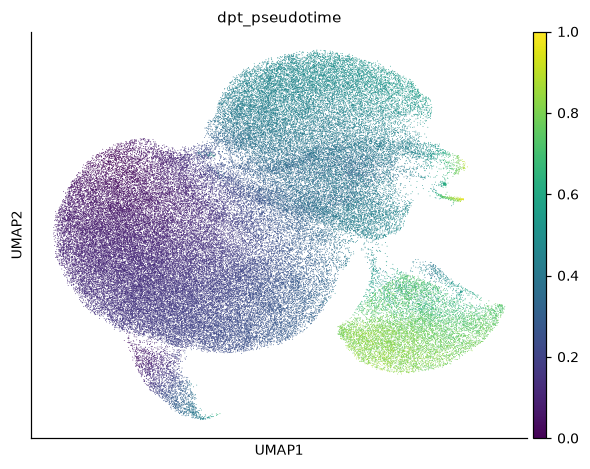

In [13]:
sc.pl.umap(cells, color=["dpt_pseudotime"])

:::{warning}
**Pseudotime is not time.** It is a distance in a graph, expressed on an arbitrary scale
from an arbitrary origin. Two things follow:

- **It has no units and no zero.** A cell at 0.4 is not "twice as far along" as one at
  0.2, and 0.4 in this notebook means nothing in anyone else's.
- **Change the root and every number changes.** Choose a root in the wrong cluster and
  you get a smooth, plausible, entirely backwards ordering. Nothing in the output will
  tell you.
:::

### Pseudotime on the diffusion map

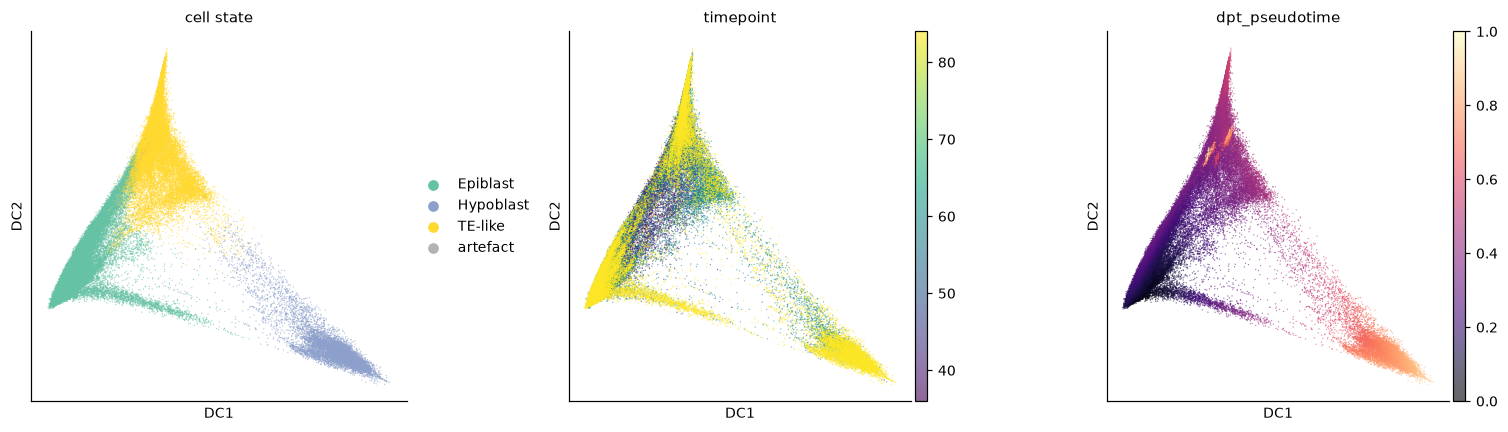

In [14]:
import scanpy as sc

# Drop the steady-state column so the new basis starts at DC1
cells.obsm["X_dc"] = cells.obsm["X_diffmap_identity"][:, 1:]
cells.obs["timepoint_num"] = cells.obs["timepoint_h"].astype(int)  # numeric -> colorbar

fig, axes = panel_grid(3, ncols=3, size=(4.6, 4.0))
panels = [
    ("cell_state",    "cell state", dict(palette="Set2")),
    ("timepoint_num", "timepoint",  dict(cmap="viridis")),
    ("dpt_pseudotime",          "dpt_pseudotime",       dict(cmap="magma", use_raw=False)),
]
for ax, (key, title, kw) in zip(axes, panels):
    sc.pl.embedding(cells, basis="dc", color=key, title=title,
                    size=3, alpha=0.6, ax=ax, show=False, **kw)
    ax.set(xlabel="DC1", ylabel="DC2")
fig.tight_layout()

### Pseudotime on the force-directed graph

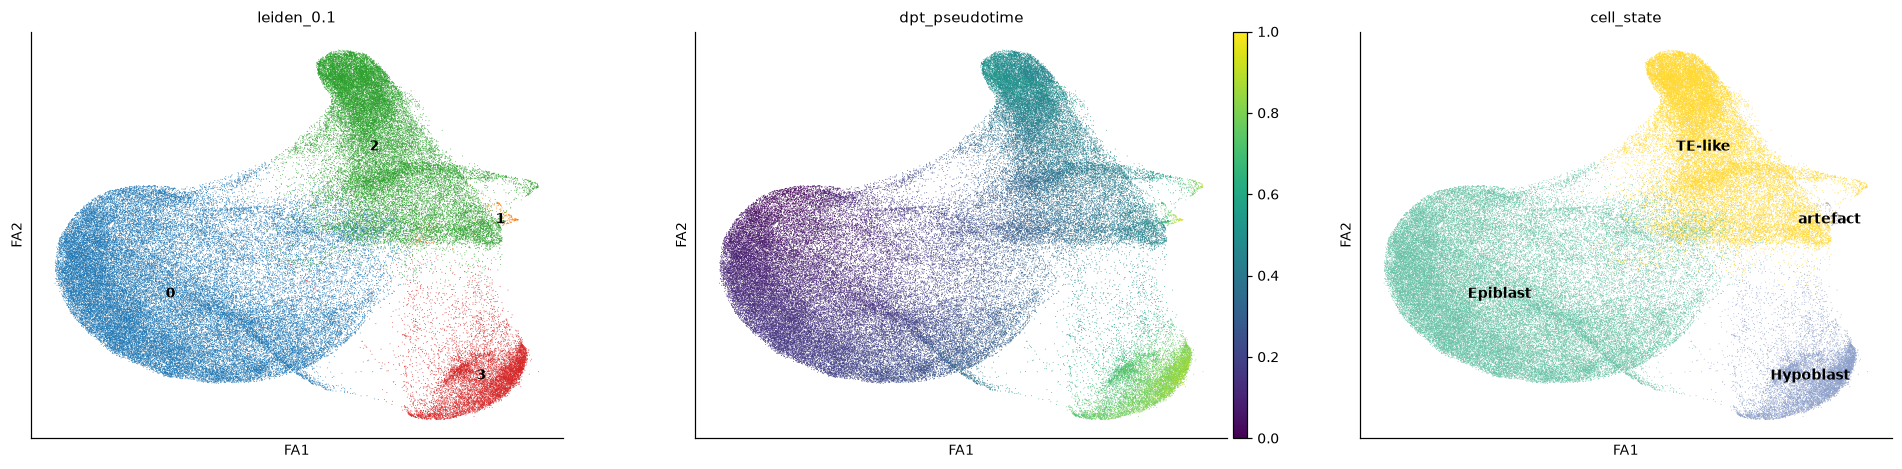

In [15]:
sc.pl.draw_graph(cells, color=["leiden_0.1", "dpt_pseudotime","cell_state"], legend_loc="on data")

## 5 · Check it before you believe it

A pseudotime always produces numbers. Two checks that it produces *meaningful* ones, and
both use information the algorithm never saw.

**Does it order the cell states the way the biology says?** Epiblast cells should sit
near the root; differentiated ones further away.

In [16]:
by_state = pd.DataFrame({"pseudotime": pseudotime,
                         "state": cells.obs.cell_state.astype(str)})
by_state.groupby("state").pseudotime.describe()[["count", "25%", "50%", "75%"]].round(3)

,count,25%,50%,75%
state,,,,
Epiblast,56017.0,0.096,0.146,0.205
Hypoblast,9773.0,0.711,0.760,0.797
TE-like,31136.0,0.375,0.420,0.458
artefact,251.0,0.581,0.741,0.839


**Does it move with the clock?** The cells were fixed at four known times. Pseudotime was
built without that column, so any agreement is real evidence — and disagreement is worth
just as much to know.

  Spearman(pseudotime, hours) = +0.089

         25%    50%    75%
hours                     
36     0.157  0.236  0.320
48     0.137  0.241  0.363
60     0.132  0.273  0.431
84     0.128  0.233  0.468


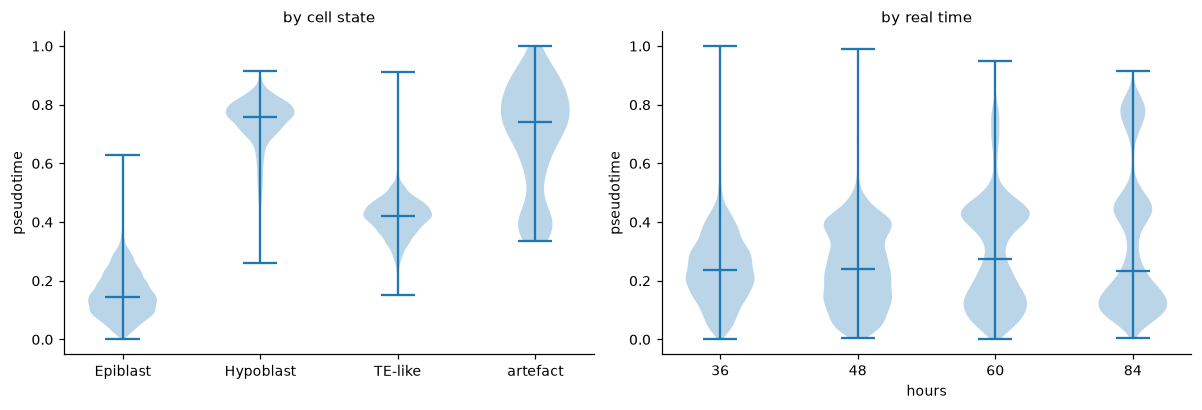

In [17]:
by_time = pd.DataFrame({"pseudotime": pseudotime,
                        "hours": cells.obs.timepoint_h.astype(int)})
print(f"  Spearman(pseudotime, hours) = {stats.spearmanr(pseudotime, by_time.hours).statistic:+.3f}\n")
print(by_time.groupby("hours").pseudotime.describe()[["25%", "50%", "75%"]].round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].violinplot([by_state.pseudotime[by_state.state == s].values
                    for s in cells.obs.cell_state.cat.categories], showmedians=True)
axes[0].set(xticks=range(1, len(cells.obs.cell_state.cat.categories) + 1),
            xticklabels=list(cells.obs.cell_state.cat.categories),
            ylabel="pseudotime", title="by cell state")

hours = sorted(by_time.hours.unique())
axes[1].violinplot([by_time.pseudotime[by_time.hours == h].values for h in hours],
                   showmedians=True)
axes[1].set(xticks=range(1, len(hours) + 1), xticklabels=hours,
            xlabel="hours", ylabel="pseudotime", title="by real time")
fig.tight_layout()

The medians rise with real time, and the epiblast cells sit lowest — so the ordering
is not arbitrary. But the correlation with the clock is weak and the distributions
overlap almost completely, which says something worth saying out loud: **most of what
separates these cells is not time.** At any one timepoint the culture contains cells all
along the axis.

That is a statement about the axis, not about any treatment. What the perturbations do to
it is a different question, and one the analysis in
[Part 4](../../part4_final_solutions/intro.md) takes up.

## 6 · Does the axis describe the rest of the plate?

Everything above was built from untreated cells, which settles one worry before it can be
raised: the axis cannot be an artefact of the perturbations, because there were none.

It raises the opposite worry instead. An axis fitted on 32 control wells is only useful to
[Part 4](../../part4_final_solutions/intro.md) if it still means the same thing on the
other 192 — and there is no reason in principle that it must. Compounds can push cells
somewhere the controls never go.

The test: build the same diffusion map on a geosketch of all eighteen conditions and see
whether DC1 comes out describing the same thing.

In [19]:
DATA_public = Path("/cluster/project/mcsliberali/data_mcs_2026")
plate = sc.read_h5ad(DATA_public / "mcs2026_sketch.h5ad")
plate.obsm["X_identity"] = np.asarray(plate[:, identity].X)
sc.pp.neighbors(plate, n_neighbors=15, use_rep="X_identity", random_state=0)
sc.tl.diffmap(plate, n_comps=10)

plate_dc = plate.obsm["X_diffmap"]
plate_oct4 = np.asarray(plate[:, "Oct4"].X).ravel()
print(f"  controls   : {cells.n_obs:,} cells, 2 conditions")
print(f"  whole plate: {plate.n_obs:,} sketched cells, {plate.obs.condition.nunique()} conditions")

/cluster/home/maaraujo/venvs/mcs2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  controls   : 97,177 cells, 2 conditions
  whole plate: 30,000 sketched cells, 18 conditions


In [20]:
plate

AnnData object with n_obs × n_vars = 30000 × 38
    obs: 'label', 'well_name', 'ROI', 'is_border_internal', 'is_border_external', 'Organoid_ID', 'timepoint_h', 'condition', 'condition_code', 'well', 'row', 'column', 'is_outlier_condition', 'area', 'eccentricity', 'solidity', 'extent', 'roundness', 'x_in_well', 'y_in_well', 'dapi', 'in_sketch'
    var: 'family', 'statistic', 'channel', 'round', 'marker', 'species', 'intensity_threshold', 'haralick_threshold', 'failed', 'is_reference', 'is_structural', 'theme', 'column'
    uns: 'decode_report', 'dropped_wells', 'panels', 'provenance', 'sketch_method', 'sketch_of', 'sketch_size', 'source_n_obs', 'themes', 'neighbors', 'diffmap_evals'
    obsm: 'X_identity', 'X_diffmap'
    layers: 'raw'
    obsp: 'distances', 'connectivities'

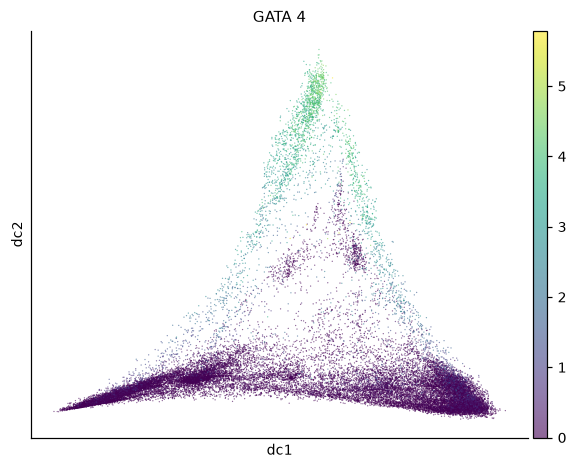

In [21]:
plate.obsm["X_dc"] = plate.obsm["X_diffmap"][:, 1:]
sc.pl.embedding(plate, basis="dc", color="GATA4", title="GATA 4",
                    size=3, alpha=0.6,show=True)


### Does DC1 still mean the same thing?

Signs are arbitrary, so compare magnitudes.

In [22]:
pd.DataFrame({
    "controls only": {
        "|Spearman| DC1 vs Oct4": abs(stats.spearmanr(dc[:, 1], oct4).statistic),
        "cells": cells.n_obs,
    },
    "all 18 conditions": {
        "|Spearman| DC1 vs Oct4": abs(stats.spearmanr(plate_dc[:, 1], plate_oct4).statistic),
        "cells": plate.n_obs,
    },
}).round(3)

,controls only,all 18 conditions
|Spearman| DC1 vs Oct4,0.852,0.873
cells,97177.000,30000.000


**The axis survives.** DC1 tracks Oct4 just as strongly when the sixteen compounds are in
the data as when they are not — so a pluripotency coordinate learned on the controls is a
pluripotency coordinate everywhere, and Part 4 can measure perturbations *against* it.


## 7 · Save

In [23]:
cells.write_h5ad(DATA / "mcs2026_controls_downstream.h5ad", compression="gzip")
print(f"  obsm : {list(cells.obsm)}")
print(f"  obs  : cell_state, dpt_pseudotime, cluster, leiden_*")
print(f"  uns  : iroot = {cells.uns['iroot']}")

  obsm : ['X_draw_graph_fa', 'X_identity', 'X_pca', 'X_pca_full', 'X_umap', 'X_umap_fullintensity', 'X_umap_identity', 'X_diffmap_identity', 'X_dc', 'X_diffmap_fullintensity', 'X_diffmap']
  obs  : cell_state, dpt_pseudotime, cluster, leiden_*
  uns  : iroot = 63750


## Stage 2 complete

| | |
|---|---|
| [05](05_the_anndata_object.ipynb) | which slot holds what, and which file to open |
| [06](06_pca.ipynb) | the axes of largest variation, and what the first one is made of |
| [07](07_umap.ipynb) | a picture, what it does not mean, and what it does on two conditions that should match |
| [08](08_cell_type_annotation.ipynb) | clusters, names, and the labels carried back to every cell |
| [09](10_diffusion_map.ipynb) | a continuous axis, the root that defines it, and a null result you can trust |

These chapters ran the pipeline on **DMSO and PBS alone**.

You now have every technique the analysis needs, and you have applied none of them to a
question. That is next: [Your turn](../11_your_turn.ipynb).

---

## Exercises

### 1. Move the root

Recompute the pseudotime from a root in the hypoblast cluster instead. What happens to
the ordering, and how would you have known it was wrong if you had not chosen the first
root yourself?

:::{admonition} Solution
:class: dropdown

```python
alt = cells.copy()
hypo = np.where(alt.obs.cell_state.astype(str) == "Hypoblast")[0]
alt.uns["iroot"] = int(hypo[np.argmin(dc[hypo, 1])])
sc.tl.dpt(alt)
print(pd.DataFrame({"pt": alt.obs.dpt_pseudotime.values,
                    "state": alt.obs.cell_state.astype(str)})
      .groupby("state").pt.median().round(3))
```

The ordering reverses, and the output is exactly as smooth and as convincing as before.
Nothing in the pseudotime itself flags it.

The only defence is external: epiblast cells at 36 hours are the starting state
because of what was put in the wells, not because of anything in the matrix. State the
root and the reason for it in your methods, every time.
:::

### 2. Does DC2 mean anything?

DC1 tracks Oct4. Correlate DC2 with every one of the 38 markers and see whether it has an
interpretation of its own, or is a second axis of the same thing.

:::{admonition} Solution
:class: dropdown

```python
X = np.asarray(cells.X)
rho = pd.Series([stats.spearmanr(dc[:, 2], X[:, i]).statistic
                 for i in range(cells.n_vars)], index=cells.var_names)
print(rho.reindex(rho.abs().sort_values(ascending=False).index).head(8).round(3))
```

Read it the way you read the PCA loadings in [chapter 06](06_pca.ipynb): if the top
correlations are all the same lineage, DC2 is a second differentiation axis; if they are
a mixture with no theme, it is structure the graph found and you cannot name — which is
a reason not to build an argument on it.
:::

---

**Next:** [Your turn](../11_your_turn.ipynb).